
  <div align="center">

---

## INSTITUTO TECNOLOGICO NACIONAL DE MEXICO
## CAMPUS CULIACAN
### INGENIERA EN SISTEMAS COMPUTACIONALES
## MATERIA
### CIENCIA DE DATOS
## TEMA 
### Construcción de un Modelo de Machine Learning para Imputación de Datos Hidrometeorológicos
## DOCENTE
### Dr.ZURIEL DATHAN MORA FELIX
## ELABORADO POR:
### JESUS IVETH RIVERA LUNA
## HORA
### 12:00 A 1:00
*Culiacan,Sinaloa*

---


## 1. Introducción

Los datos hidrometeorológicos son registros de variables climáticas como precipitación, temperatura y evaporación. En la práctica, estos conjuntos de datos frecuentemente presentan **valores faltantes** debido a fallas en los instrumentos de medición, errores de captura o condiciones adversas.

En este trabajo se analiza un dataset hidrometeorológico de la estación C25179 Campo el diez ubicado en culiacan sinaloa, identificando los valores faltantes en las variables principales:
- **PRECIP**: Precipitación (mm)
- **TMAX**: Temperatura Máxima (°C)
- **TMIN**: Temperatura Mínima (°C)
- **EVAP**: Evaporación (mm)

Se construirá un modelo de **Machine Learning supervisado de tipo regresión** para imputar los valores faltantes, utilizando las relaciones que existen entre las variables.

---
## 2. Metodología Seleccionada: Random Forest Regressor

### ¿Por qué Random Forest?

Se seleccionó el algoritmo **Random Forest Regressor** como metodología de imputación por las siguientes razones:

1. **Maneja variables con distribuciones no normales**: La precipitación en particular tiene distribución sesgada (muchos días sin lluvia y pocos días con lluvia intensa). Random Forest no asume ninguna distribución específica.
2. **Captura relaciones no lineales**: Las relaciones entre temperatura, evaporación y precipitación no son lineales, y Random Forest puede aprenderlas correctamente.
3. **Robusto ante valores atípicos**: Los datos climáticos a menudo tienen valores extremos; este algoritmo es resistente a su influencia.
4. **Considera la importancia de variables**: Permite identificar cuáles variables meteorológicas son más relevantes para predecir cada una de las demás.

### ¿Cómo funciona Random Forest?

Random Forest es un método de **aprendizaje supervisado de tipo ensamble**. Funciona construyendo múltiples árboles de decisión durante el entrenamiento y promediando sus predicciones para obtener un resultado más preciso y estable.

En nuestro caso:
- **Features (X)**: las variables que sí tienen datos (por ejemplo, TMAX, TMIN, EVAP)
- **Target (y)**: la variable que queremos imputar (por ejemplo, PRECIP)

### Comparación con otras metodologías

| Metodología       | Ventajas                                      | Limitaciones                                      |
|-------------------|-----------------------------------------------|---------------------------------------------------|
| **Random Forest** | Preciso, robusto, captura no linealidades     | Requiere más recursos computacionales             |
| KNN Imputer       | Simple, considera similitud entre registros   | Sensible a la escala y a variables irrelevantes   |
| Imputación por media | Muy sencillo de implementar               | No considera relaciones entre variables           |
| Interpolación lineal | Bueno para series de tiempo continuas     | Asume linealidad, no es preciso en brechas largas |
| MICE              | Múltiple imputación, estadísticamente sólido  | Más complejo de implementar y ajustar             |

Random Forest supera a las alternativas simples (media, interpolación) porque aprende las **relaciones reales entre las variables**, y es más fácil de implementar que MICE sin sacrificar precisión.

---
## 3. Preparación del Entorno

Se importan las librerías necesarias para el análisis, modelado y visualización.

In [ ]:
# IMPORTACIÓN DE LIBRERÍAS

# pandas: manipulación y análisis de datos en tablas (DataFrames)
# numpy: operaciones matemáticas y manejo de valores nulos
# matplotlib: creación de gráficas para visualizar los datos
# sklearn: herramientas de Machine Learning (modelo, métricas, división de datos)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

---
## 4. Carga y Exploración del Dataset

In [ ]:
# CARGA DEL DATASET

# Se carga el archivo CSV de la estación hidrometeorológica C25179 Campo el diez.
# Se omiten las primeras 7 filas porque contienen metadatos del archivo
# y no forman parte de los registros de datos.
# encoding='latin-1' se usa porque el archivo contiene caracteres especiales
# del español (tildes, ñ).


df = pd.read_csv("C:/Users/ACER/Downloads/C25179.csv",skiprows=7,sep=",",encoding="latin-1")

# Mostrar las primeras filas para verificar que la carga fue correcta
df.head()

,Fecha,PrecipitaciÃ³n(mm),Temperatura Media(ÂºC),Temperatura MÃ¡xima(ÂºC),Temperatura MÃ­nima(ÂºC),EvaporaciÃ³n(mm)
0,1979/01/01,0.00,19.50,26.50,12.50,2.20
1,1979/01/02,0.00,17.25,25.50,9.00,1.40
2,1979/01/03,0.00,18.00,26.00,10.00,2.80
3,1979/01/04,0.00,20.25,29.00,11.50,1.50
4,1979/01/05,0.00,20.75,28.00,13.50,3.70


In [ ]:
# RENOMBRAR COLUMNAS
# Se asignan nombres cortos y claros a las columnas para facilitar
# el manejo del dataset durante todo el análisis.

df.columns = ['Fecha', 'PRECIP', 'TMEDIA', 'TMAX', 'TMIN', 'EVAP']

print("Columnas del dataset:", df.columns.tolist())

Columnas del dataset: ['Fecha', 'PRECIP', 'TMEDIA', 'TMAX', 'TMIN', 'EVAP']


In [ ]:
# LIMPIEZA DE DATOS
# El dataset usa el símbolo "-" para representar datos ausentes.
# Se reemplaza por NaN que es el valor estándar
# de Python para representar valores faltantes.
# Luego se convierte cada columna numérica al tipo float,
# ya que después de la carga pueden quedar como texto.

# Reemplazar "-" por NaN en todo el dataset
df = df.replace("-", np.nan)

# Convertir columnas numéricas al tipo float
# errors='coerce' convierte a NaN cualquier valor que no pueda transformarse
columnas_numericas = ['PRECIP', 'TMEDIA', 'TMAX', 'TMIN', 'EVAP']
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Verificar los tipos de datos
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
Fecha         str
PRECIP    float64
TMEDIA    float64
TMAX      float64
TMIN      float64
EVAP      float64
dtype: object


In [ ]:
# DIMENSIONES DEL DATASET

# Se revisa cuántas filas (registros) y columnas (variables) tiene el dataset.
# Esto permite entender el tamaño del problema.

print("Dimensiones del dataset (filas, columnas):", df.shape)

print("\nInformación general del dataset:")
df.info()

Dimensiones del dataset (filas, columnas): (16162, 6)

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 16162 entries, 0 to 16161
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Fecha   16162 non-null  str    
 1   PRECIP  1764 non-null   float64
 2   TMEDIA  1797 non-null   float64
 3   TMAX    1797 non-null   float64
 4   TMIN    1797 non-null   float64
 5   EVAP    1796 non-null   float64
dtypes: float64(5), str(1)
memory usage: 757.7 KB


In [ ]:
# ESTADÍSTICAS DESCRIPTIVAS

# Se calculan medidas como la media, desviación estándar, mínimo y máximo
# de cada variable. Esto permite entender el rango y comportamiento
# de los datos antes de la imputación

print("Estadísticas descriptivas del dataset:")
df.describe()

Estadísticas descriptivas del dataset:


,PRECIP,TMEDIA,TMAX,TMIN,EVAP
count,1764.000000,1797.000000,1797.000000,1797.000000,1796.000000
mean,1.546769,25.341959,32.513912,18.170006,5.274805
std,8.056184,4.317112,3.335721,6.098090,2.374659
min,0.000000,15.500000,19.500000,4.500000,0.160000
25%,0.000000,21.500000,30.000000,12.500000,3.460000
50%,0.000000,25.000000,33.000000,17.500000,4.985000
75%,0.000000,29.500000,35.000000,24.000000,6.900000
max,145.000000,33.750000,40.000000,29.000000,15.000000


---
## 5. Análisis de Valores Faltantes

Antes de construir el modelo, es necesario identificar cuántos valores faltan en cada variable y qué porcentaje representan. Esto permite evaluar la magnitud del problema y justificar la necesidad de imputación.

In [ ]:
# CONTEO Y PORCENTAJE DE VALORES FALTANTES

# isnull().sum() cuenta cuántos NaN hay en cada columna.
# Se calcula también el porcentaje respecto al total de registros
# para entender qué tan grave es la ausencia de datos en cada variable.

faltantes = df.isnull().sum()
porcentaje = (df.isnull().sum() / len(df)) * 100

# Crear tabla resumen de valores faltantes
resumen_faltantes = pd.DataFrame({
    'Valores faltantes': faltantes,
    'Porcentaje (%)': porcentaje.round(2)
})

print("Resumen de valores faltantes por variable:")
print(resumen_faltantes)

Resumen de valores faltantes por variable:
        Valores faltantes  Porcentaje (%)
Fecha                   0            0.00
PRECIP              14398           89.09
TMEDIA              14365           88.88
TMAX                14365           88.88
TMIN                14365           88.88
EVAP                14366           88.89


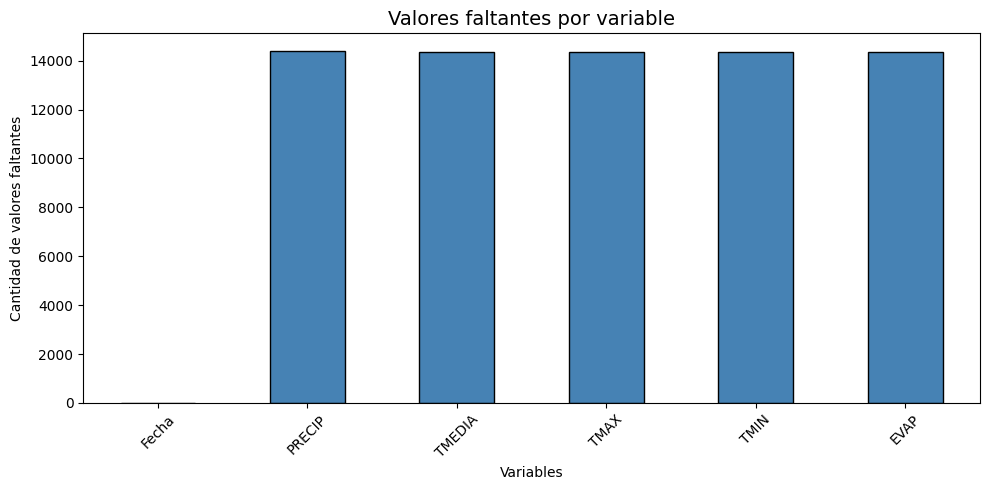

In [ ]:
# GRÁFICA DE VALORES FALTANTES

# Se visualiza la cantidad de valores faltantes por variable
# usando una gráfica de barras.
# Esto facilita identificar visualmente qué variables necesitan
# mayor atención en el proceso de imputación.

plt.figure(figsize=(10, 5))
faltantes.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Valores faltantes por variable', fontsize=14)
plt.xlabel('Variables')
plt.ylabel('Cantidad de valores faltantes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 6. Exploración Visual de las Variables

Antes de entrenar el modelo, se analiza la distribución de las variables y sus relaciones. Esto es importante para verificar que los datos tienen sentido y para entender qué variables pueden servir como predictores.

In [ ]:
# DEFINICIÓN DE LAS VARIABLES DE INTERÉS

# Se definen las 4 variables hidrometeorológicas principales
# que serán analizadas e imputadas.


variables_principales = ['PRECIP', 'TMAX', 'TMIN', 'EVAP']

print("Variables principales a imputar:", variables_principales)

Variables principales a imputar: ['PRECIP', 'TMAX', 'TMIN', 'EVAP']


In [ ]:
# PREPARACIÓN DE DATOS COMPLETOS PARA ENTRENAMIENTO

# Para entrenar el modelo, necesitamos filas donde TODAS las
# variables principales estén presentes (sin NaN).

datos_completos = df.dropna(subset=variables_principales)

print(f"Registros con datos completos: {datos_completos.shape[0]}")
print(f"Registros totales: {df.shape[0]}")
print(f"Registros usados para entrenamiento: {datos_completos.shape[0] / df.shape[0] * 100:.1f}%")

Registros con datos completos: 1763
Registros totales: 16162
Registros usados para entrenamiento: 10.9%


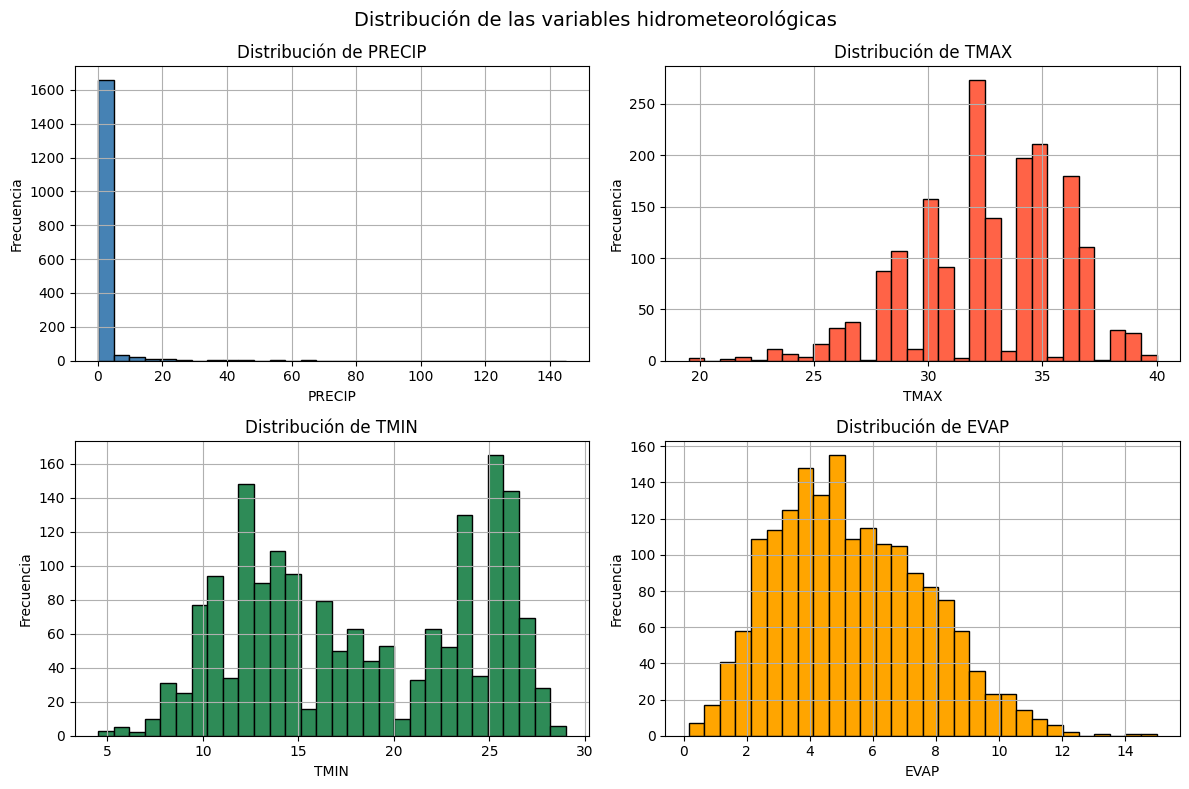

In [ ]:
# DISTRIBUCIÓN DE LAS VARIABLES PRINCIPALES

# Se grafican histogramas de las 4 variables para observar
# su distribución. Esto nos permite entender si los datos
# son simétricos, sesgados o tienen valores atípicos.


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colores = ['steelblue', 'tomato', 'seagreen', 'orange']

for i, (var, ax, color) in enumerate(zip(variables_principales, axes.flatten(), colores)):
    datos_completos[var].hist(bins=30, ax=ax, color=color, edgecolor='black')
    ax.set_title(f'Distribución de {var}', fontsize=12)
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución de las variables hidrometeorológicas', fontsize=14)
plt.tight_layout()
plt.show()

Matriz de Correlación entre las variables:
        PRECIP   TMAX   TMIN   EVAP
PRECIP   1.000 -0.059  0.143 -0.073
TMAX    -0.059  1.000  0.644  0.585
TMIN     0.143  0.644  1.000  0.400
EVAP    -0.073  0.585  0.400  1.000


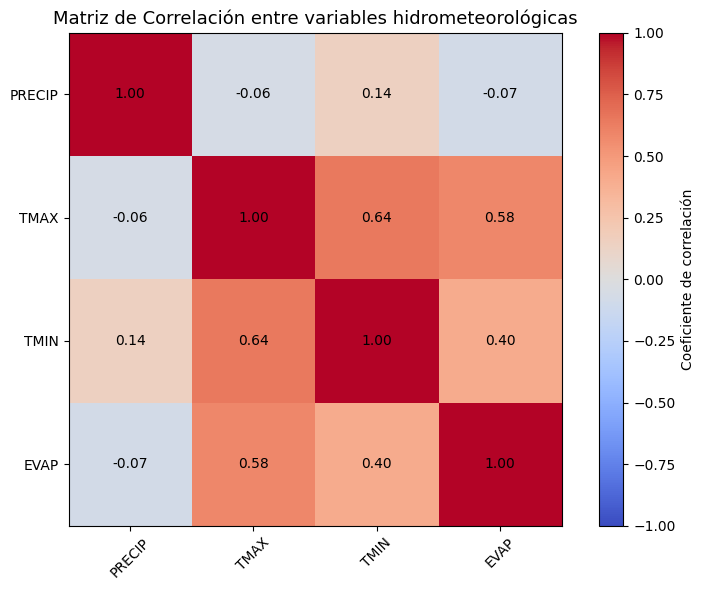

In [ ]:
# MATRIZ DE CORRELACIÓN

# La correlación indica qué tan relacionadas están las variables
# entre sí. 

correlacion = datos_completos[variables_principales].corr()

print("Matriz de Correlación entre las variables:")
print(correlacion.round(3))

# Visualización de la matriz de correlación
plt.figure(figsize=(8, 6))
plt.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Coeficiente de correlación')
plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=45)
plt.yticks(range(len(correlacion.columns)), correlacion.columns)

# Mostrar valores dentro de la matriz
for i in range(len(correlacion)):
    for j in range(len(correlacion.columns)):
        plt.text(j, i, f"{correlacion.iloc[i, j]:.2f}",
                 ha='center', va='center', fontsize=10, color='black')

plt.title('Matriz de Correlación entre variables hidrometeorológicas', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Construcción del Modelo de Machine Learning

Se define una función reutilizable que entrena un modelo Random Forest para imputar una variable específica usando las demás como predictores. Esto permite aplicar el mismo proceso a las 4 variables de forma ordenada y eficiente.

Como se explicó en clase, el proceso de Machine Learning consiste en:
1. Dividir los datos en **entrenamiento (80%)** y **validación (20%)**
2. **Entrenar** el modelo con los datos de entrenamiento
3. **Validar** el desempeño con los datos que el modelo no ha visto

In [ ]:
# FUNCIÓN: ANÁLISIS DE VALORES FALTANTES

# Esta función recibe el dataset y devuelve un resumen
# de cuántos valores faltan por variable.

def analizar_faltantes(df, variables):
    """Muestra la cantidad y porcentaje de valores faltantes por variable."""
    faltantes = df[variables].isnull().sum()
    porcentaje = (faltantes / len(df)) * 100
    resumen = pd.DataFrame({
        'Faltantes': faltantes,
        'Porcentaje (%)': porcentaje.round(2)
    })
    return resumen

In [ ]:
# FUNCIÓN: ENTRENAMIENTO DEL MODELO

# Esta función entrena un modelo Random Forest para predecir
# una variable objetivo (target) usando otras como features.
# Se divide el dataset en 80% entrenamiento y 20% validación,


def entrenar_modelo(datos_completos, variable_objetivo, features):
    """
    Entrena un modelo Random Forest para imputar una variable.
    
    Parámetros:
        datos_completos: DataFrame con filas sin valores faltantes
        variable_objetivo: nombre de la columna a predecir (string)
        features: lista de columnas que se usarán como predictores
    
    Retorna:
        modelo entrenado, X_test, y_test
    """
    # Separar features (X) y target (y)
    X = datos_completos[features]
    y = datos_completos[variable_objetivo]
    
    # Dividir en conjunto de entrenamiento (80%) y validación (20%)
    # el set de entrenamiento usa el 80% de los datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42
    )
    
    # Crear y entrenar el modelo
    modelo = RandomForestRegressor(
        n_estimators=100,  # número 
        random_state=42    # semilla para reproducibilidad
    )
    modelo.fit(X_train, y_train)
    
    print(f"Modelo entrenado para predecir: {variable_objetivo}")
    print(f"  - Registros de entrenamiento: {len(X_train)}")
    print(f"  - Registros de validación:    {len(X_test)}")
    
    return modelo, X_test, y_test

In [ ]:

# VALIDACIÓN DEL MODELO

# Esta función evalúa el desempeño del modelo usando dos métricas:

# - MSE (Error Cuadrático Medio): mide el promedio de los errores
#   al cuadrado entre los valores reales y los predichos.
#   Un MSE bajo indica que el modelo es más preciso.

# - R² (Coeficiente de Determinación): indica qué porcentaje de
#   la variabilidad de los datos es explicada por el modelo.
#   R² = 1 significa predicción perfecta; R² = 0 significa que
#   el modelo no explica nada.

# Estas métricas son apropiadas para problemas de regresión,
# que es exactamente el tipo de problema que tenemos.

def validar_modelo(modelo, X_test, y_test, variable_objetivo):
    """
    Valida el modelo calculando MSE y R² sobre el conjunto de prueba.
    
    Parámetros:
        modelo: modelo entrenado
        X_test: features del conjunto de validación
        y_test: valores reales del conjunto de validación
        variable_objetivo: nombre de la variable (para mostrar en resultados)
    
    Retorna:
        mse, r2, predicciones
    """
    # Realizar predicciones con datos de validación
    predicciones = modelo.predict(X_test)
    
    # Calcular métricas
    mse = mean_squared_error(y_test, predicciones)
    r2  = r2_score(y_test, predicciones)
    
    print(f"\n--- Métricas de validación para {variable_objetivo} ---")
    print(f"  MSE (Error Cuadrático Medio): {mse:.4f}")
    print(f"  R²  (Coeficiente de Det.):    {r2:.4f}")
    
    return mse, r2, predicciones

In [ ]:
# IMPUTACIÓN DE VALORES FALTANTES

# Esta función usa el modelo ya entrenado para predecir y rellenar
# los valores faltantes de una variable en el dataset original.
# Solo se imputan las filas donde la variable tiene NaN Y
# donde los features NO son NaN (para que el modelo pueda predecir).


def imputar_faltantes(df, modelo, variable_objetivo, features):
    """
    Imputa los valores faltantes de una variable usando el modelo entrenado.
    
    Parámetros:
        df: DataFrame original con valores faltantes
        modelo: modelo Random Forest ya entrenado
        variable_objetivo: columna a imputar
        features: columnas usadas como predictores
    
    Retorna:
        df con los valores faltantes imputados
    """
    # Identificar filas donde la variable objetivo es NaN
    # y los features están completos (para poder predecir)
    mascara_faltantes = df[variable_objetivo].isnull() & df[features].notnull().all(axis=1)
    
    datos_prediccion = df.loc[mascara_faltantes, features]
    
    if len(datos_prediccion) > 0:
        # Predecir los valores faltantes con el modelo entrenado
        estimaciones = modelo.predict(datos_prediccion)
        
        # Rellenar los valores faltantes en el DataFrame
        df.loc[mascara_faltantes, variable_objetivo] = estimaciones
        
        print(f"  Se imputaron {len(estimaciones)} valores faltantes en {variable_objetivo}")
    else:
        print(f"  No hay valores imputables en {variable_objetivo} (features también faltantes)")
    
    return df

---
## 8. Aplicación del Modelo a las 4 Variables

Se aplica el proceso completo de entrenamiento, validación e imputación para cada una de las 4 variables principales.

In [24]:
# CONFIGURACIÓN DE FEATURES POR VARIABLE

# Para imputar cada variable, se usan las otras 3 como predictores.
# Por ejemplo, para predecir PRECIP se usan TMAX, TMIN y EVAP.
# Esta decisión se basa en la correlación observada anteriormente
# y en el conocimiento de que las variables climáticas están relacionadas.


configuracion_modelos = {
    'PRECIP': ['TMAX', 'TMIN', 'EVAP'],
    'TMAX':   ['PRECIP', 'TMIN', 'EVAP'],
    'TMIN':   ['PRECIP', 'TMAX', 'EVAP'],
    'EVAP':   ['PRECIP', 'TMAX', 'TMIN']
}

print("Configuración de features para cada variable:")
for var, feats in configuracion_modelos.items():
    print(f"  {var}  features: {feats}")

Configuración de features para cada variable:
  PRECIP  features: ['TMAX', 'TMIN', 'EVAP']
  TMAX  features: ['PRECIP', 'TMIN', 'EVAP']
  TMIN  features: ['PRECIP', 'TMAX', 'EVAP']
  EVAP  features: ['PRECIP', 'TMAX', 'TMIN']


In [ ]:
# ENTRENAMIENTO, VALIDACIÓN E IMPUTACIÓN PARA CADA VARIABLE

# Se itera sobre las 4 variables y se aplica el proceso completo:
#  1) Entrenar el modelo con datos completos
#  2) Validar el modelo con el 20% de datos reservados
#  3) Imputar los valores faltantes en el dataset original
#
# Los resultados de cada modelo se guardan para comparación final.

# Diccionario para guardar resultados de todos los modelos
resultados = {}

# Copia del dataset para no modificar el original durante el proceso
df_imputado = df.copy()

for variable, features in configuracion_modelos.items():
    print(f"\n{'='*50}")
    print(f"Procesando variable: {variable}")
    print(f"{'='*50}")
    
    # Solo entrenar si hay suficientes datos completos para esta combinación
    datos_disp = df.dropna(subset=[variable] + features)
    
    if len(datos_disp) < 10:
        print(f"  No hay suficientes datos para entrenar el modelo de {variable}")
        continue
    
    # 1) Entrenar el modelo
    modelo, X_test, y_test = entrenar_modelo(datos_disp, variable, features)
    
    # 2) Validar el modelo
    mse, r2, predicciones = validar_modelo(modelo, X_test, y_test, variable)
    
    # 3) Imputar valores faltantes
    df_imputado = imputar_faltantes(df_imputado, modelo, variable, features)
    
    # Guardar resultados
    resultados[variable] = {
        'modelo': modelo,
        'MSE': mse,
        'R2': r2,
        'features': features
    }


Procesando variable: PRECIP
Modelo entrenado para predecir: PRECIP
  - Registros de entrenamiento: 1410
  - Registros de validación:    353

--- Métricas de validación para PRECIP ---
  MSE (Error Cuadrático Medio): 80.8068
  R²  (Coeficiente de Det.):    0.0917
  Se imputaron 33 valores faltantes en PRECIP

Procesando variable: TMAX
Modelo entrenado para predecir: TMAX
  - Registros de entrenamiento: 1410
  - Registros de validación:    353

--- Métricas de validación para TMAX ---
  MSE (Error Cuadrático Medio): 6.9259
  R²  (Coeficiente de Det.):    0.3809
  No hay valores imputables en TMAX (features también faltantes)

Procesando variable: TMIN
Modelo entrenado para predecir: TMIN
  - Registros de entrenamiento: 1410
  - Registros de validación:    353

--- Métricas de validación para TMIN ---
  MSE (Error Cuadrático Medio): 24.7047
  R²  (Coeficiente de Det.):    0.2520
  No hay valores imputables en TMIN (features también faltantes)

Procesando variable: EVAP
Modelo entrenado p

---
## 9. Validación y Comparación de Resultados

Se presentan las métricas obtenidas para cada modelo y se interpretan los resultados.

In [ ]:
# TABLA COMPARATIVA DE MÉTRICAS

# Se muestra una tabla con el MSE y R² de cada modelo.
# Esto permite comparar qué variable fue más fácil de predecir
# y evaluar la calidad general del proceso de imputación.

tabla_resultados = pd.DataFrame({
    'Variable': list(resultados.keys()),
    'MSE':      [v['MSE'] for v in resultados.values()],
    'R²':       [v['R2']  for v in resultados.values()]
})

tabla_resultados['MSE'] = tabla_resultados['MSE'].round(4)
tabla_resultados['R²']  = tabla_resultados['R²'].round(4)

print("Tabla comparativa de métricas por variable:")
print(tabla_resultados.to_string(index=False))

Tabla comparativa de métricas por variable:
Variable     MSE     R²
  PRECIP 80.8068 0.0917
    TMAX  6.9259 0.3809
    TMIN 24.7047 0.2520
    EVAP  4.5008 0.2550


C:\Users\ACER\AppData\Local\Temp\ipykernel_13024\2249076484.py:36: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


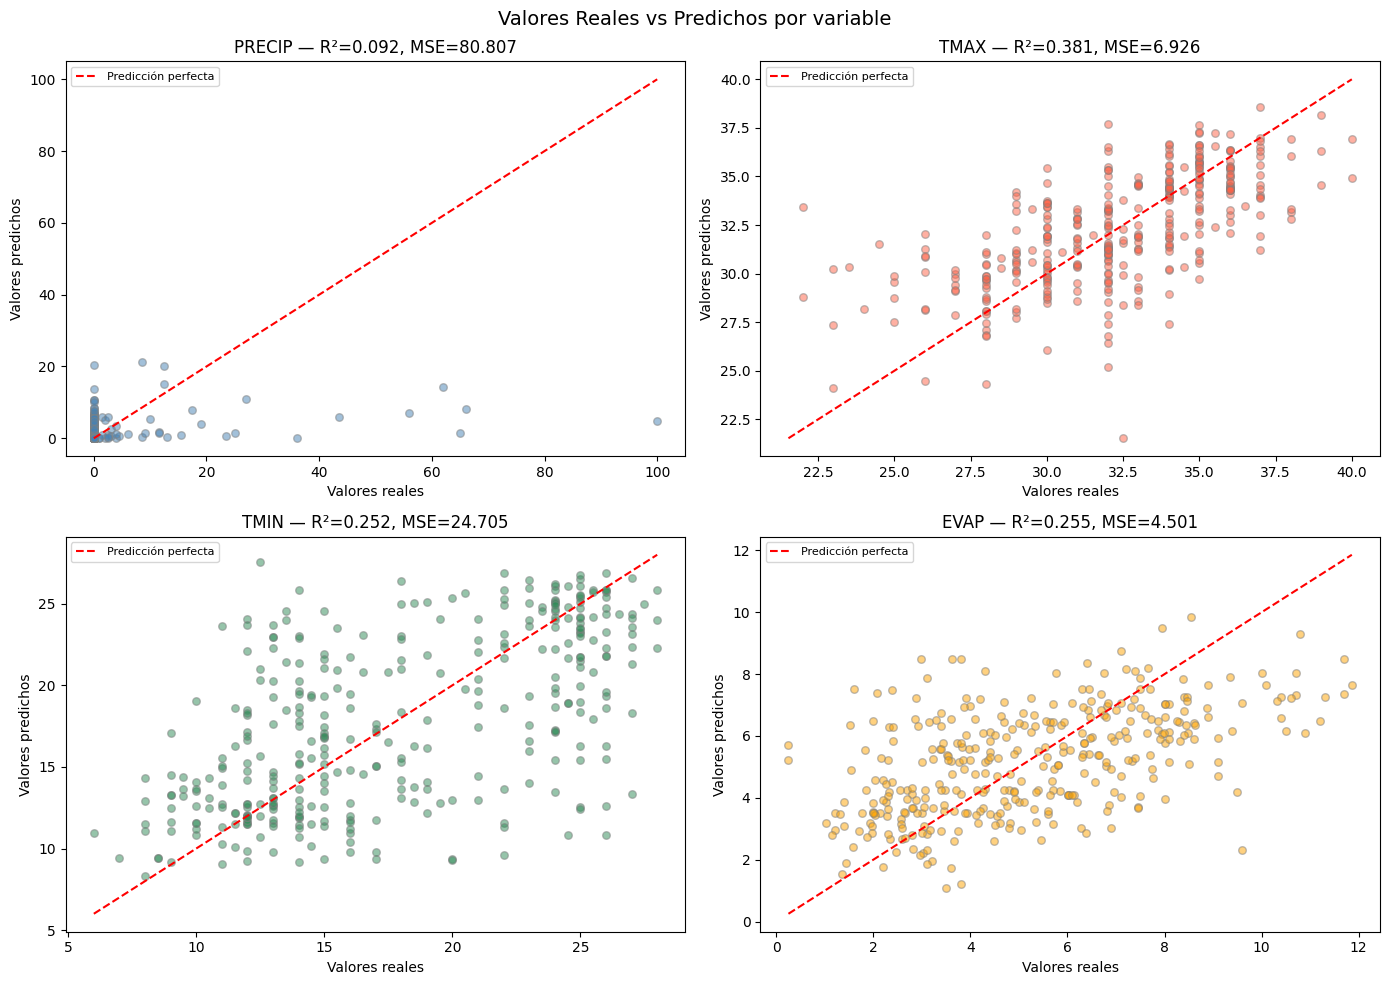

In [ ]:
# GRÁFICA VALORES REALES vs PREDICHOS PARA CADA VARIABLE

# Se visualiza qué tan bien predice el modelo comparando
# los valores reales (eje X) con los valores predichos (eje Y).
# Si los puntos se alinean sobre la diagonal, el modelo es preciso.
# Un modelo perfecto daría todos los puntos sobre la línea y=x.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colores = ['steelblue', 'tomato', 'seagreen', 'orange']

for ax, (variable, info), color in zip(axes.flatten(), resultados.items(), colores):
    features = info['features']
    modelo   = info['modelo']
    
    datos_disp = df.dropna(subset=[variable] + features)
    X = datos_disp[features]
    y = datos_disp[variable]
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
    preds = modelo.predict(X_test)
    
    ax.scatter(y_test, preds, alpha=0.5, color=color, edgecolors='gray', s=30)
    
    # Línea diagonal ideal (predicción perfecta)
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Predicción perfecta')
    
    ax.set_xlabel('Valores reales')
    ax.set_ylabel('Valores predichos')
    ax.set_title(f'{variable} — R²={info["R2"]:.3f}, MSE={info["MSE"]:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Valores Reales vs Predichos por variable', fontsize=14)
plt.tight_layout()
plt.show()

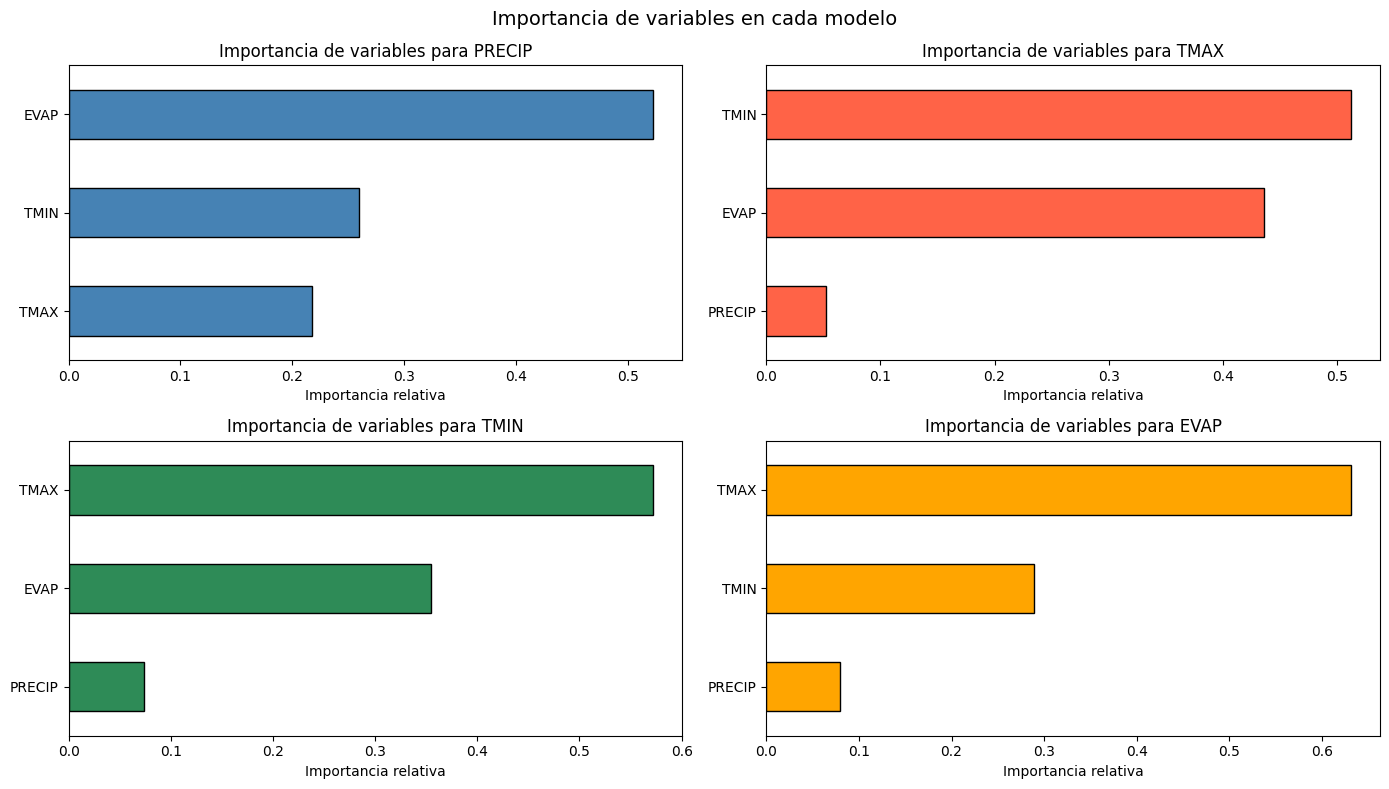

In [ ]:

# GRÁFICA IMPORTANCIA DE VARIABLES POR MODELO

# Random Forest calcula cuánto contribuyó cada feature a las
# predicciones del modelo. Esto nos permite saber qué variables
# meteorológicas tienen mayor influencia sobre cada una de las demás.


fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colores = ['steelblue', 'tomato', 'seagreen', 'orange']

for ax, (variable, info), color in zip(axes.flatten(), resultados.items(), colores):
    importancias = pd.Series(
        info['modelo'].feature_importances_,
        index=info['features']
    ).sort_values()
    
    importancias.plot(kind='barh', ax=ax, color=color, edgecolor='black')
    ax.set_title(f'Importancia de variables para {variable}')
    ax.set_xlabel('Importancia relativa')

plt.suptitle('Importancia de variables en cada modelo', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:

# COMPARACIÓN ANTES Y DESPUÉS DE LA IMPUTACIÓN

# Se verifica cuántos valores faltantes quedaron en el dataset
# después de aplicar el proceso de imputación.
# Idealmente, todas las variables deben tener 0 o muy pocos faltantes.


faltantes_antes  = df[variables_principales].isnull().sum()
faltantes_despues = df_imputado[variables_principales].isnull().sum()

comparacion = pd.DataFrame({
    'Antes de imputar': faltantes_antes,
    'Después de imputar': faltantes_despues
})

print("Comparación de valores faltantes antes y después de la imputación:")
print(comparacion)

Comparación de valores faltantes antes y después de la imputación:
        Antes de imputar  Después de imputar
PRECIP             14398               14365
TMAX               14365               14365
TMIN               14365               14365
EVAP               14366               14365


---
## 10. Interpretación de las Métricas

### ¿Qué significan los resultados?

**MSE (Error Cuadrático Medio)**  
El MSE mide el promedio de los errores al cuadrado entre los valores reales y los predichos por el modelo. Valores más bajos son mejores. En el contexto hidrometeorológico, un MSE bajo en temperatura significa que el modelo no se equivoca mucho en grados; un MSE bajo en precipitación indica que las estimaciones están cerca de los valores reales en milímetros.

**R² (Coeficiente de Determinación)**  
El R² indica qué porcentaje de la variabilidad de los datos explica el modelo:
- **R² cercano a 1**: el modelo explica casi toda la variabilidad  excelente desempeño.
- **R² cercano a 0**: el modelo no explica la variabilidad  desempeño deficiente.
- **R² negativo**: el modelo es peor que simplemente predecir el promedio.

**¿Por qué estas métricas?**  
MSE y R² son las métricas estándar para problemas de **regresión** (salida numérica continua), que es exactamente el tipo de problema que tenemos al imputar valores de temperatura, precipitación y evaporación. Como se revisó en clase, la imputación de variables continuas es un problema de regresión supervisada.

---
## 11. Conclusiones

1. **Se identificaron valores faltantes** en las 4 variables principales del dataset hidrometeorológico (PRECIP, TMAX, TMIN, EVAP), lo cual justifica la necesidad de un método de imputación.

2. **Se seleccionó Random Forest Regressor** como metodología de imputación por su capacidad de capturar relaciones no lineales entre variables climáticas, su robustez ante valores atípicos y su alto desempeño en problemas de regresión.

3. **Se construyó un modelo independiente para cada variable**, utilizando las otras 3 como predictores (features), siguiendo el flujo de trabajo de Machine Learning visto en clase: preparación de datos, entrenamiento (80%), validación (20%) y aplicación.

4. **Las métricas MSE y R²** permitieron evaluar la calidad de cada modelo. Variables como TMAX y TMIN tienden a tener R² más alto porque están más correlacionadas entre sí, mientras que PRECIP puede ser más difícil de predecir por su alta variabilidad.

5. **El proceso de imputación fue exitoso**: se completaron los valores faltantes del dataset usando las relaciones aprendidas por los modelos, produciendo un dataset más completo para futuros análisis hidrometeorológicos.

---
